In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 



# Plot

In [2]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [3]:
precision=1e-10

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_RES'

In [72]:
# ws = 2000000
# ws = 1000000
# ws = 100000
# ws = 50000  # Might be too big
# ws = 30000  # might be too big
# ws = 10000
# ws=5000
ws = 3000
# ws=500
# ws=300

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS{ws}'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [73]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [74]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [75]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [76]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [77]:
# calcualte entropy without 0-insertion windows
for bc in tn5_insert_freq.keys():
    if bc not in entropy_df.index:
        continue
    else:
        cur, freq = np.unique(tn5_insert_freq[bc].toarray(), return_counts=True)
        freq_log = freq * np.log2(freq + 1)  # rescale frequence 
        if cur[0] == 0:
            freq_none = freq[1:]
            cur_none = cur[1:]
        else:
            freq_none = freq
            cur_none = cur


        total_windows = freq.sum() 
        

        non0_p = freq_none / np.sum(freq_none)
        non0_mean = np.sum(cur_none * non0_p)
        non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)



        M1 = freq_none.sum()

        a = (non0_2ndorder_moment - non0_mean**2) / (non0_mean)


        if a  < precision:
            Nwindows_0inser_open_region = None
        else:
            Nwindows_0inser_open_region = np.max((np.floor(M1 / a  - M1 ), 0))
            Nwindows_0inser_open_region = np.min((Nwindows_0inser_open_region, total_windows - M1))


        if Nwindows_0inser_open_region is None or Nwindows_0inser_open_region < precision:
            Nwindows_closed_region = total_windows - M1
            total_non0_ocur = np.concatenate((cur_none, [Nwindows_closed_region]))
        elif Nwindows_0inser_open_region - (total_windows - M1) < precision:
            total_non0_ocur = np.concatenate((cur_none, [Nwindows_0inser_open_region]))
        else:
            Nwindows_closed_region = total_windows - M1 - Nwindows_0inser_open_region
            total_non0_ocur = np.concatenate((cur_none, [Nwindows_0inser_open_region, Nwindows_closed_region]))

        # calculate entropy

        p_final = total_non0_ocur / total_windows


        entropy_final = -np.sum(p_final * np.log2(p_final))
        entropy_df.loc[bc, 'entropy_mixdist'] = entropy_final

        
        

In [78]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000214,0.000387
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.004289,0.007591
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.012653,0.012816


## Load CR's barcodes info 

In [79]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [80]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['Cluster'].isna()

In [81]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist,Cluster,log(total_fragments),log(entropy),cr_bc
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,NaN,6.020600e-01,NaN,False
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000214,0.000387,NaN,4.342945e-11,-3.668993,False
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.004289,0.007591,NaN,2.315970e+00,-2.367667,False
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,NaN,4.342945e-11,NaN,False
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.012653,0.012816,NaN,2.994317e+00,-1.897816,False


## See correlation between 0-insertion windows & entropy value


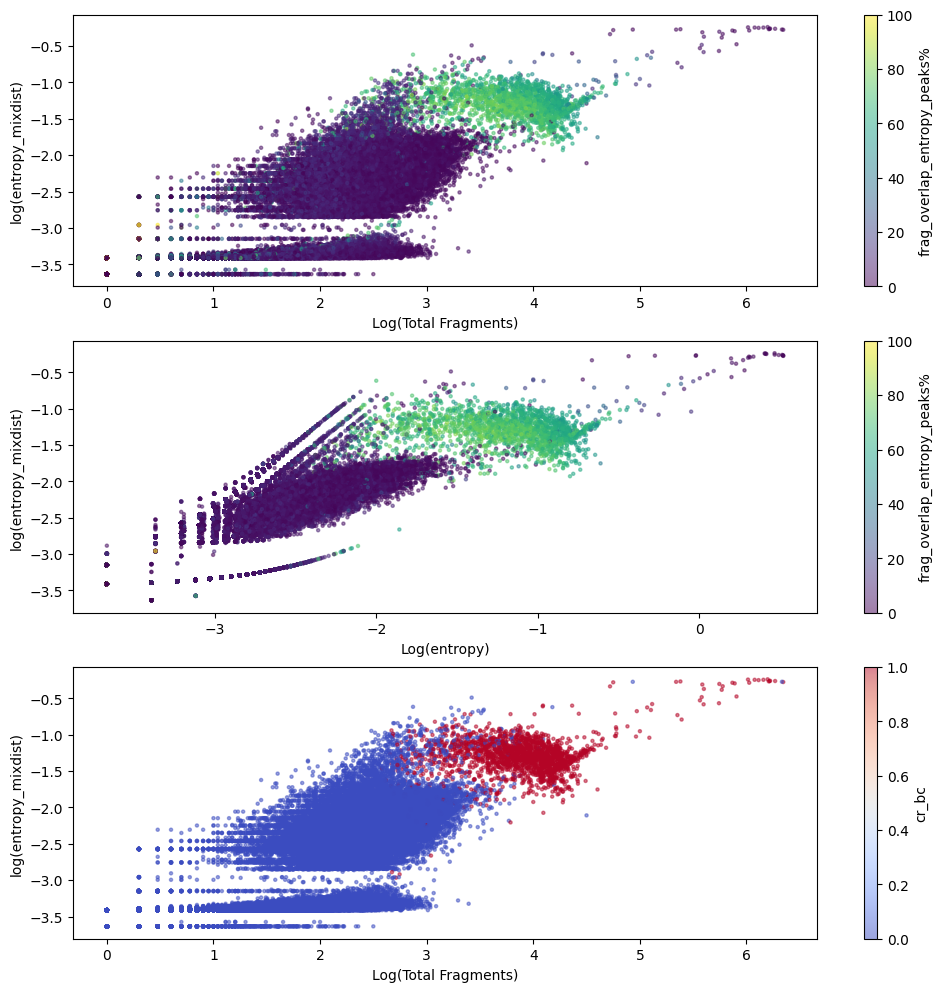

In [82]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')


{'bodies': [<matplotlib.collections.PolyCollection at 0x724b5f87a550>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x724b60394b90>,
 'cmins': <matplotlib.collections.LineCollection at 0x724b5f75e090>,
 'cbars': <matplotlib.collections.LineCollection at 0x724b62107e50>}

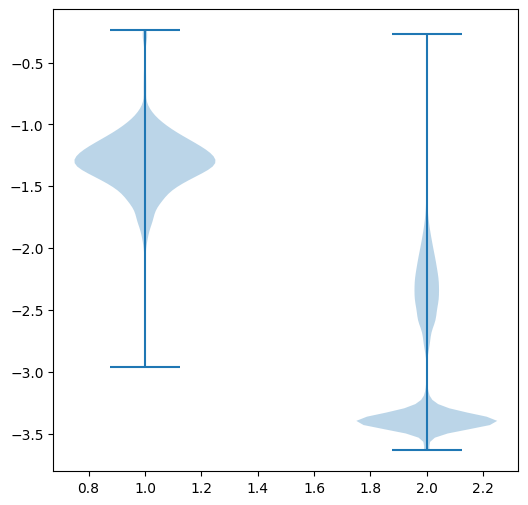

In [109]:
fig, ax = plt.subplots(figsize=(6,6))
ax.violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist'].dropna()+ precision)],
               showmeans=False)

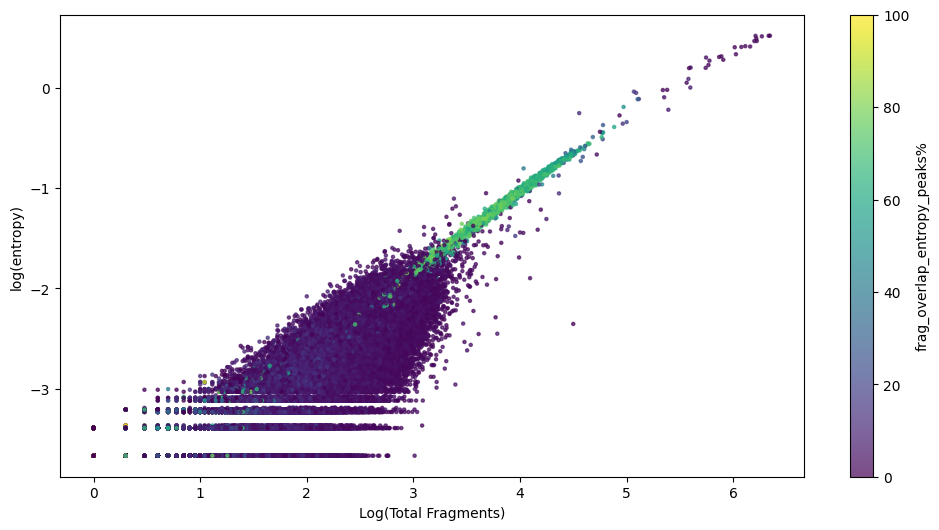

In [83]:
fig, ax = plt.subplots(figsize=(12,6))

ax.scatter( all_df['log(total_fragments)'], all_df['log(entropy)'], c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.7, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy)')
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

In [91]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)

In [92]:
top20k_df.describe()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist,Cluster,log(total_fragments),log(entropy)
count,2.000000e+04,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,19987.000000,19987.000000,1959.000000,20000.000000,19987.000000
mean,2.791678e+03,648.358400,11.198212,2.791678e+03,645.710450,11.148348,0.015662,0.013431,3.068402,2.805108,-2.314678
std,4.203905e+04,2446.030955,19.750838,4.203905e+04,2434.721875,19.693132,0.088758,0.027138,1.834695,0.428333,0.510564
min,2.700000e+02,0.000000,0.000000,2.700000e+02,0.000000,0.000000,0.000214,0.000232,1.000000,2.431364,-3.668993
25%,3.440000e+02,14.000000,2.860747,3.440000e+02,14.000000,2.838639,0.002360,0.003902,1.000000,2.536558,-2.626996
50%,4.650000e+02,20.000000,4.198974,4.650000e+02,20.000000,4.175365,0.004117,0.006421,3.000000,2.667453,-2.385420
75%,7.690000e+02,33.000000,6.534091,7.690000e+02,33.000000,6.493506,0.007374,0.010833,5.000000,2.885926,-2.132318
max,2.214078e+06,47889.000000,85.128205,2.214078e+06,47745.000000,85.034965,3.313464,0.577639,7.000000,6.345193,0.520282


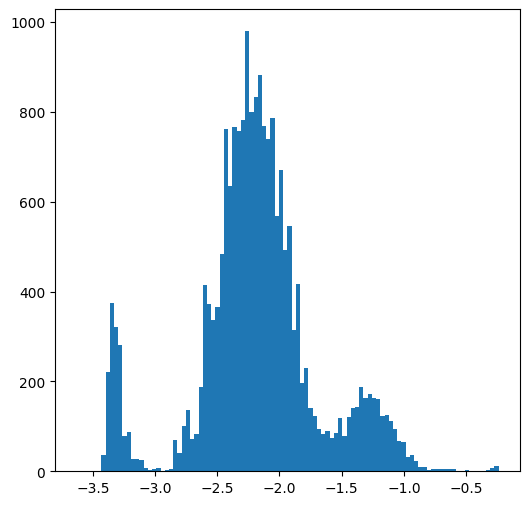

In [93]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['entropy_mixdist']+ precision), bins=100)

In [97]:
all_df['cr_bc'].value_counts()

cr_bc
False    287050
True       1959
Name: count, dtype: int64

Text(0.5, 0, 'Ranked Barcodes (by entropy_mixdist)')

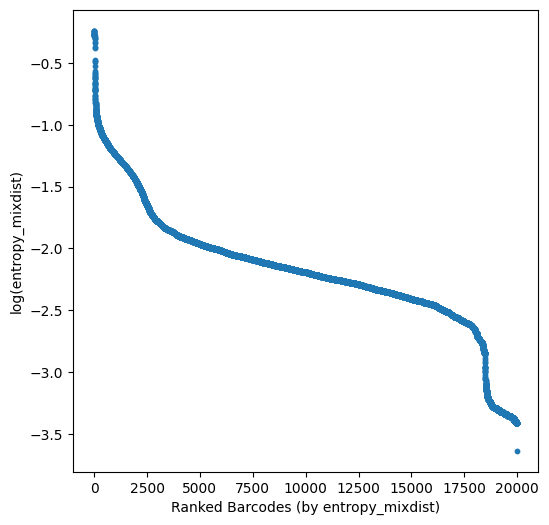

In [96]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['entropy_mixdist'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(entropy_mixdist)')
ax.set_xlabel('Ranked Barcodes (by entropy_mixdist)')

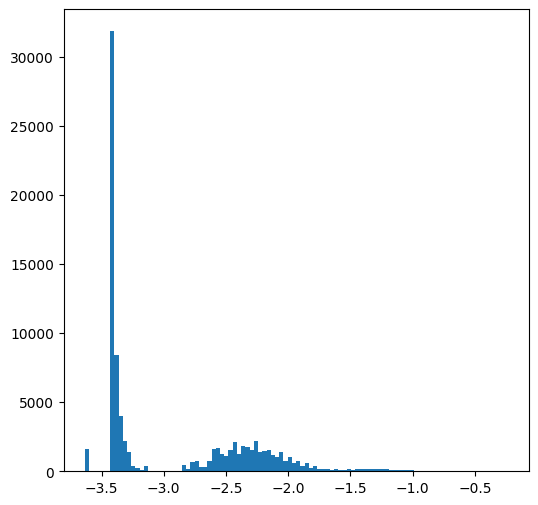

In [87]:
fig,ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(all_df['entropy_mixdist']+ precision), bins=100)

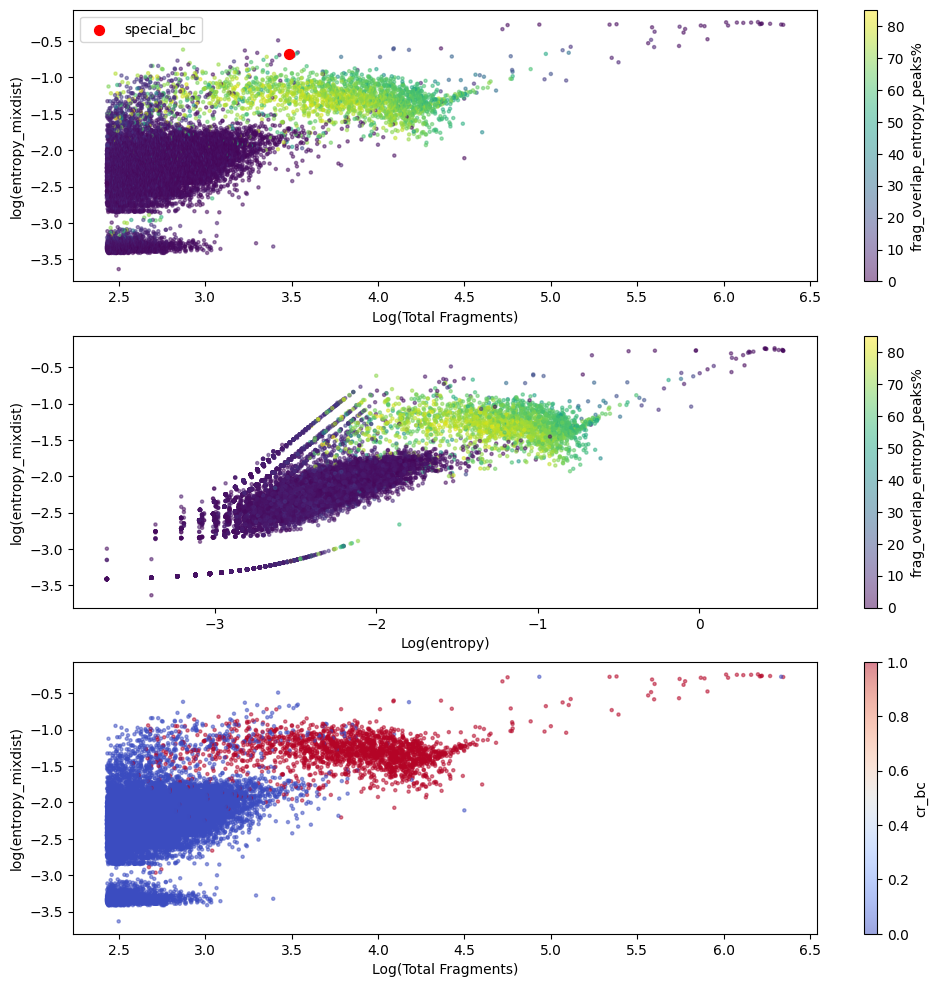

In [88]:
special_bc = 'AGCTAACAGCCTGGTT-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( top10k_df['log(total_fragments)'], np.log10(top10k_df['entropy_mixdist']+ precision), c=top10k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
ax[0].scatter(top10k_df.loc[special_bc, 'log(total_fragments)'], np.log10(top10k_df.loc[special_bc, 'entropy_mixdist']+ precision),
              color='red', s=50, label='special_bc')
ax[0].legend()


ax[1].scatter(top10k_df['log(entropy)'], np.log10(top10k_df['entropy_mixdist']), c=top10k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')



ax[2].scatter(top10k_df['log(total_fragments)'], np.log10(top10k_df['entropy_mixdist']+ precision),  c=top10k_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')

fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

In [104]:
lam = 3
(  np.exp(-lam) ) * lam

0.14936120510359183

# Misc

# Subset only BCs with particular seq-depth  (II) Plots on Tn5 insertions-log scale. 